# Projet ENMO

Dépôt GitHub : https://github.com/SaidRodriguez22/Physical-activity-00.git
 
### Membres du groupe:

- Rosy Boutouom-Messu
- Daniel Reyes
- Said Rodriguez
- Zakia Hammaini


### Objectif
 
L'objectif est de calculer l'ENMO à partir des données d'accélérométrie puis de comparer l'activité physique obtenue pour différentes durées d'époque: 10s, 30s et 60s.

In [3]:
pip install pandas

   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.8 MB 2.3 MB/s eta 0:00:05
   ---- ----------------------------------- 1.0/9.8 MB 2.3 MB/s eta 0:00:04
   ----- ---------------------------------- 1.3/9.8 MB 2.1 MB/s eta 0:00:05
   ------- -------------------------------- 1.8/9.8 MB 2.0 MB/s eta 0:00:05
   -------- ------------------------------- 2.1/9.8 MB 2.0 MB/s eta 0:00:04
   ---------- ----------------------------- 2.6/9.8 MB 2.0 MB/s eta 0:00:04
   ------------- -------------------------- 3.4/9.8 MB 2.1 MB/s eta 0:00:03
   ---------------- ----------------------- 3.9/9.8 MB 2.2 MB/s eta 0:00:03
   ------------------- -------------------- 4.7/9.8 MB 2.4 MB/s eta 0:00:03
   --------------------- ------------------ 5.2/9.8 MB 2.4 MB/s eta 0:00:02
   ------------------------- -------------- 6.3/9.8 MB 2.6 MB/s eta 0:00:02
   -----------------------

In [7]:
# Importer les bibliothèques 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Charger le fichier
df = pd.read_csv("0_z.csv", comment="#")
df.head()

,t,x,y,z
0,0.00,-0.0938,-0.0156,0.9531
1,0.02,-0.0938,-0.0156,0.9531
2,0.04,-0.0938,-0.0156,0.9531
3,0.06,-0.0938,-0.0156,0.9531
4,0.08,-0.0938,-0.0156,0.9531


## Lecture des données

Le fichier contient :

- t : temps en secondes
- x : accélération selon l'axe X
- y : accélération selon l'axe Y
- z : accélération selon l'axe Z

Ces mesures proviennent d'un accéléromètre porté au poignet non dominant.

### Calcul de l'ENMO

L'ENMO (Euclidean Norm Minus One) est utilisé pour mesurer l'activité physique.

La norme vectorielle est calculée à partir des trois axes.

La composante gravitationnelle d'environ 1g est ensuite retirée.

Les valeurs négatives sont remplacées par 0.

In [8]:
# Code du calcul ENMO
vm = np.sqrt(
    df["x"]**2 +
    df["y"]**2 +
    df["z"]**2
)

df["enmo"] = np.maximum(vm - 1, 0)

df.head()

,t,x,y,z,enmo
0,0.00,-0.0938,-0.0156,0.9531,0.0
1,0.02,-0.0938,-0.0156,0.9531,0.0
2,0.04,-0.0938,-0.0156,0.9531,0.0
3,0.06,-0.0938,-0.0156,0.9531,0.0
4,0.08,-0.0938,-0.0156,0.9531,0.0


### Utilisation de fonctions
Les fonctions permettent :

- d'éviter la répétition de code
- d'améliorer la lisibilité
- de faciliter la maintenance du programme

In [9]:
# Fonction d'intégration
def integrate_enmo(df, epoch_duration):

    temp = df.copy()

    temp["epoch"] = (
        temp["t"] // epoch_duration
    ).astype(int)

    integrated = temp.groupby(
        "epoch"
    )["enmo"].sum()

    return integrated

In [13]:
# Fonction de tracé
def plot_enmo(df, epoch_duration):

    integrated = integrate_enmo(
        df,
        epoch_duration
    )

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(10,6)
    )

    axes[0].bar(
        range(len(integrated)),
        integrated,
        color="lightgrey"
    )

    axes[0].set_title(
        f"ENMO integrated over {epoch_duration} s intervals"
    )

    axes[0].set_ylabel(
        "Integrated ENMO"
    )

    axes[1].plot(
        df["t"]/60,
        df["enmo"],
        color="skyblue"
    )

    axes[1].set_title(
        "ENMO over Time"
    )

    axes[1].set_xlabel(
        "Time (minutes)"
    )

    axes[1].set_ylabel(
        "ENMO (g)"
    )

    plt.tight_layout()
    plt.show()

### Intégration par époque

Une époque correspond à une fenêtre de temps pendant laquelle les données sont regroupées.

Trois durées sont étudiées :

- 10 secondes
- 30 secondes
- 60 secondes

Cela permet d'observer l'effet de la taille de la fenêtre sur la mesure d'activité.

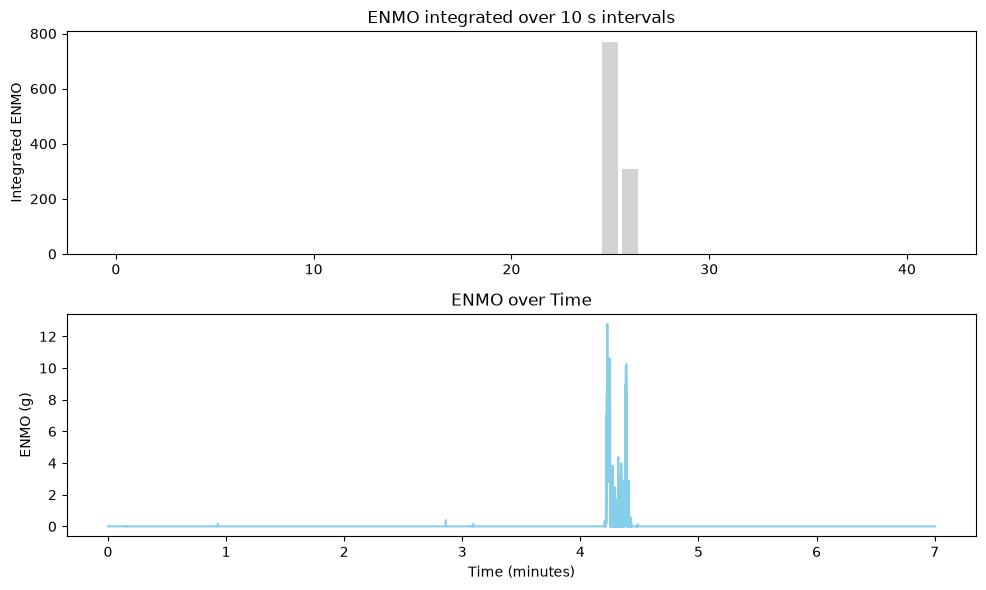

In [14]:
plot_enmo(df, 10)

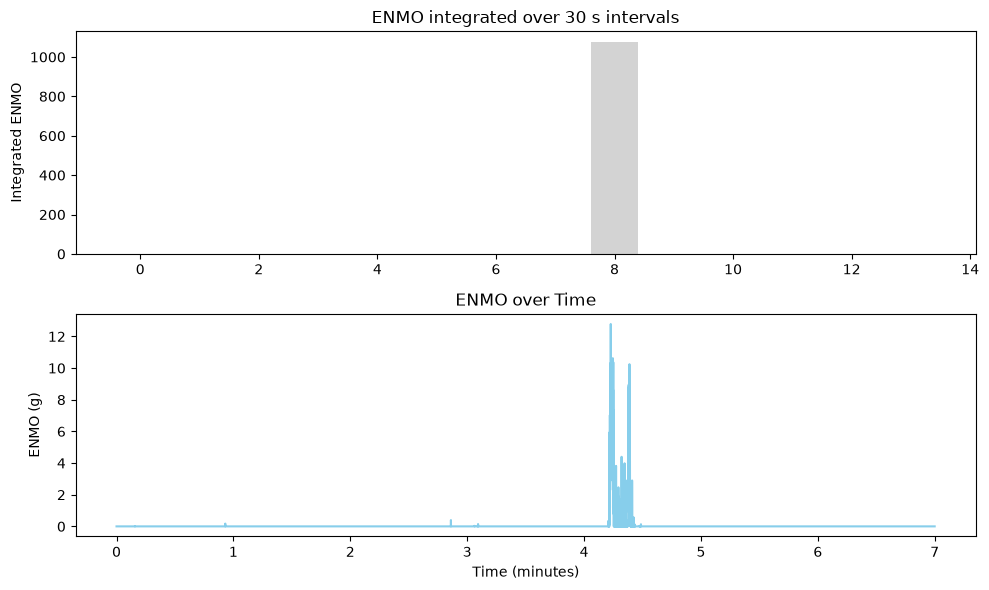

In [15]:
plot_enmo(df, 30)

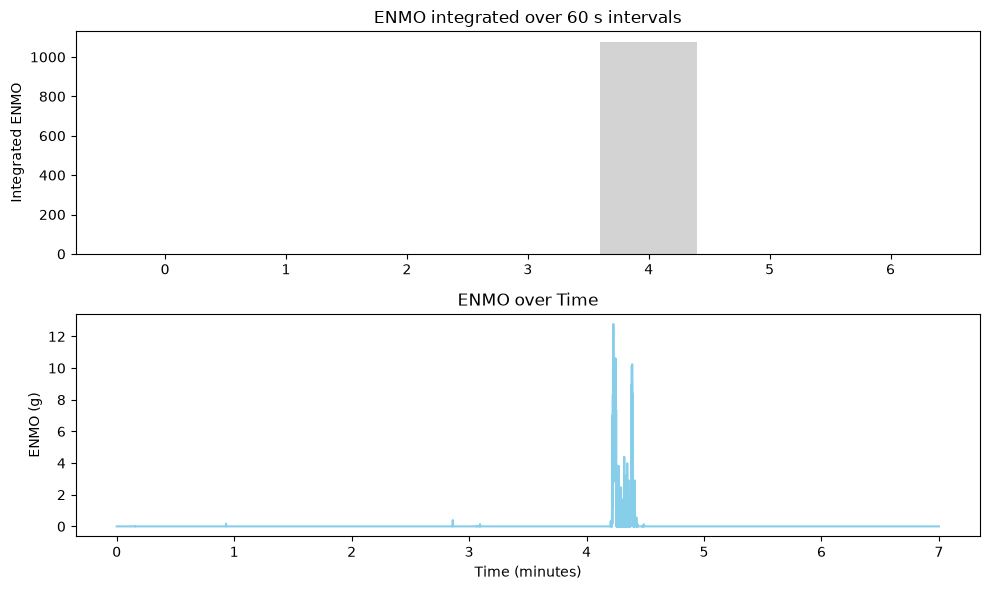

In [16]:
plot_enmo(df, 60)

### Utilisation de Copilot

Prompts utilisés :

- Crée une fonction Python pour calculer l'ENMO à partir des colonnes x y z.
- Crée une fonction pour intégrer l'ENMO sur des époques de temps.
- Crée une fonction permettant de tracer les graphiques demandés.

Modifications effectuées :

- Vérification des calculs.
- Adaptation des titres des graphiques.
- Ajout des commentaires et explications.